In [22]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as scp
from scipy.signal import find_peaks
from sklearn.mixture import GaussianMixture,BayesianGaussianMixture

In [23]:
#Conversions
boundary_  = lambda p:p.view(np.uint32) >> 16    
flag_      = lambda p:p.view(np.uint32) & 0xffff

identity_ = lambda p:p.view(np.uint32)[3,1]   
primIdx_   = lambda p:identity_(p) >> 16  
instanceId_  = lambda p:identity_(p) & 0xffff  

idx_      = lambda p:p.view(np.uint32)[3,2] & 0x7fffffff
orient_   = lambda p:p.view(np.uint32)[3,2] >> 31

flagmask_ = lambda p:p.view(np.uint32)


In [24]:
## Root 

In [25]:
import uproot

In [26]:
def GetValues(file):
    val=uproot.open(file)
    Values={}
    ### Diffusion
    folder="ntuple"
    subfolder="Diffusion"
    Keys=np.array(["Event","Efield","dl","dt","vd"])
    
    Dic1={}
    for key in Keys:
        Dic1[key]=np.array(val[folder][subfolder][key].array())
        
    Values[subfolder]=Dic1
    
    ## EL
    Dic2={}
    subfolder="EL"
    Keys=np.array(["Event","Time","X","Y","Z"])
    for key in Keys:
        if(key!="Event" and key!="Time"):
            #print(key)
            Dic2[key]=np.array(val[folder][subfolder][key].array())*10
        else:
            Dic2[key]=np.array(val[folder][subfolder][key].array())
    Values[subfolder]=Dic2
    
    ## Camera
    Dic3={}
    Dic4={}
    subfolders=["Opticks_Camera_Hits","Opticks_PMT_Hits"]
    Keys=np.array(["Event","t","x","y","z"])
    for key in Keys:
        Dic3[key]=np.array(val[folder][subfolders[0]][key].array())
        Dic4[key]=np.array(val[folder][subfolders[1]][key].array())
        
    Values["Camera"]=Dic3
    Values["PMT"]=Dic4
    
    return Values



def Gauss1D(x,Ampl,mean,sigma):
    return Ampl*np.exp(-(x-mean)**2/(2*(sigma)**2)) 



def Sumsof3Gaussian(xy,*initials):
    fit1=initials[0:5]
    fit2=initials[5:10]
    fit3=initials[10:15]
    offset=initials[-1:]
    Sum=TwoDGaussian(xy,*fit1)+TwoDGaussian(xy,*fit2)+TwoDGaussian(xy,*fit3)+offset
    return Sum.ravel()

def FitSumsof3Gaussian(img,fit1,fit2,fit3,offset,it=15000):
    x = np.linspace(0,img.shape[0],img.shape[0])
    xx, yy = np.meshgrid(x, x)
    flattened=img.ravel()
    popt, pcov = sci.curve_fit(Sumsof3Gaussian, (xx, yy),flattened , p0=(*fit1,*fit2,*fit3,offset),maxfev=it,method="dogbox")
    print(popt)
    data_fitted = Sumsof3Gaussian((xx, yy),*popt)
    return flattened.reshape(img.shape[0],img.shape[1]),data_fitted.reshape(img.shape[0],img.shape[1]),[xx,yy],popt

def Sumof1DGaussians(x,*ip):
    Sum=np.zeros_like(x)
    N=len(ip)
    for i in range(0,N,3):
        #print(f"{i}_Initials Amp {ip[i]} ,Mean {ip[i+1]}, Sigma {ip[i+2]}")
        Sum=Sum+Gauss1D(x,ip[i],ip[i+1],ip[i+2])
        
    return Sum
def TwoDGaussian(xy,Amp,x0,sigmax,y0,sigmay=None,offset=1):
    x,y=xy
    if(sigmay==None):
        sigmay=sigmax
    value=Amp*np.exp(-((x-x0)**2/(2*sigmax**2)+(y-y0)**2/(2*sigmay**2)))+offset
    return value

def SumofTwoDGaussian(xy,*ip):
    x,y=xy
    Sum=np.zeros_like(x)
    N=len(ip)
    for i in range(0,N,6):
        #print(f"Lengt{i}_Initials Amp {ip[i]} ,Mean {ip[i+1]}, Sigma {ip[i+2]}")
        Sum=Sum+TwoDGaussian(xy,ip[i],ip[i+1],ip[i+2],ip[i+3],ip[i+4],ip[i+5])
    return Sum

def FitSumsof_N_1DGaussian(X,ax=None,NGaussians=7,binsize=200,Maxiterr=1000,isPlot=True,isPrint=True,isPlotGM=False):
    if(ax==None):
        fig,ax=plt.figure(figsize=(15,8),dpi=300)
    if(isPlot):    
        hist=ax.hist(X,bins=np.linspace(np.min(X),np.max(X),binsize))
    else:
        hist=np.histogram(X,bins=np.linspace(np.min(X),np.max(X),binsize))
    #Estimate inital values using Gaussian Mixtures
    k=X.reshape(-1,1) # Reshape the data from [0,0,0]  to [[0],[0]]
    ## This method uses the Gaussian Mixture from scipy 
    gm=GaussianMixture(n_components=NGaussians,covariance_type="full",max_iter=Maxiterr).fit(k)

    amp=gm.weights_.ravel()
    ### This is for scaling the amplitudes to match to histogram ines
    MaxAmp=np.max(amp)
    MaxHistAmpl=np.max(hist[0])
    weightScale=MaxHistAmpl/MaxAmp
    
    
    amp=amp*weightScale
    
    
    mean=gm.means_.ravel()
    #print(f"Covariances is {gm.covariances_}")
    sigma=np.sqrt(gm.covariances_.ravel())
    if(isPrint):
        print(f"amps {amp}")
        print(f"means {mean}")
        print(f"sigmas {sigma}")

    ## This is to check how the gaussians are looking
    if(isPlotGM):
        Test=np.zeros_like(X)
        for i in range(0,NGaussians):
            ax.plot(np.sort(X),Gauss1D(np.sort(X),amp[i],mean[i],sigma[i]),color="orange")
        Test+=Gauss1D(np.sort(X),amp[i],mean[i],sigma[i])
        #print(gm.weights_[i]*8000)
    ## Sum of the N Gaussians

    initials=np.array([])
    tlist=[amp,mean,sigma]
    for i in range(0,NGaussians):
        for p in range(0,3):
            initials=np.append(initials,tlist[p][i])
    print("------ Initials ------")
    print(initials)
    fit=scp.curve_fit(Sumof1DGaussians,hist[1][:-1],hist[0],p0=initials)
    ### Find Peaks
    if(isPlot):
        GaussianSum=Sumof1DGaussians(np.sort(X),*fit[0])
        peaks,_=find_peaks(np.sort(X),height=GaussianSum)
        print(f"Peaks {peaks}")
        ax.plot(np.sort(X),GaussianSum,alpha=1,color="brown",linewidth=3,linestyle="dashed",label="optimize")
        ax.plot(peaks,GaussianSum[peaks],"x")
    ## Total Sigma
    TotalSigma=0
    Sigmas=np.array([])
    for i in range(0,len(fit[0]),3):
        TotalSigma+=abs(fit[0][i+2])**2
        Sigmas=np.append(Sigmas,fit[0][i+2])
    print(f"Sigma Values {Sigmas} and  Total {TotalSigma}")    
    String_=r'$\mu$' +f" = {round(np.sqrt(TotalSigma),2)}"
    if(isPrint):
        print("Fit Results")
        print(fit[0])
        
    if(isPlotGM):
        ax.plot(np.sort(X),Test,color="green",alpha=1,label="GM")

    if(isPlot):
        ax.text(np.min(X),np.max(fit[0])*0.9,s=String_,color="brown")    
        ax.legend()
    print("-------------- Fit Results --------------")    
    print(fit)
    return fit[0],Sigmas


def Fit2DGaussian(img,initials,offset,it=15000,bins=None):
    if(bins==None):
        x = np.linspace(0,img.shape[0],img.shape[0])
        x=y
    else:
        x = bins[0][:-1]
        y = bins[1][:-1]

    xx, yy = np.meshgrid(x, y)
    flattened=img.ravel()
    popt, pcov = scp.curve_fit(TwoDGaussian, (xx.ravel(), yy.ravel()),flattened ,p0=(*initials,offset),maxfev=it)
    data_fitted = TwoDGaussian((xx, yy),*popt)
    return flattened.reshape(img.shape[0],img.shape[1]),data_fitted.reshape(img.shape[0],img.shape[1]),[xx,yy],popt


def FitSumsof_N_2DGaussian(X,Y,ax=None,binsize=300,NGaussians=2,Maxiterr=5000,isPlot=True,isPrint=True):
    if(ax==None and isPlot):
        fig,ax=plt.figure(figsize=(15,8),dpi=300)
    xbins=np.linspace(np.min(X),np.max(X),binsize)
    ybins=np.linspace(np.min(Y),np.max(Y),binsize)
    bins_=[xbins,ybins]
    if(isPlot):
        h2=ax.hist2d(X,Y,bins=bins_,cmap="hot")
    else:
        h2=np.histogram2d(X,Y,bins=bins_)
    ## for somereason histograming introduces weird rotation this helps to get back the same image    
    h=np.rot90(h2[0],1)
    h=np.flip(h,0)

    ## Estimate Gaussian Mixture
    k=np.vstack((X, Y)).T

    pp=GaussianMixture(n_components=NGaussians,covariance_type="full",max_iter=Maxiterr,n_init=1,reg_covar=1e-6).fit(k)
    ## Obtain the fitting results
    amps=pp.weights_.ravel()
    means=pp.means_.ravel()
    covariances=pp.covariances_
    covariances=np.diagonal(covariances.T).ravel()
    sigmas=np.sqrt(covariances)
    if (isPrint):
        print(f"Amp {amps}")
        print(f"Means {means}")
        print(f"sigma {sigmas}")
    
    ## Get Initials
    ii=np.array([])
    count=0
    for i in range(0,len(amps)):
        ii=np.append(ii,amps[i])
        for v in range(0,2):
            ii=np.append(ii,np.array([means[count],sigmas[count]]))
            count=count+1
        ii=np.append(ii,0)
    if(isPrint):
        print(f"Initials {ii}")
    x_=np.linspace(np.min(X),np.max(X),binsize-1)
    y_=np.linspace(np.min(Y),np.max(Y),binsize-1)    
    xx_,yy_=np.meshgrid(x_,y_)
    
    fit=scp.curve_fit(SumofTwoDGaussian,(xx_.ravel(),yy_.ravel()),h.ravel(),p0=ii)
    if(isPlot):
        ax.contour(xx_,yy_,SumofTwoDGaussian((xx_,yy_),*fit[0]),colors="white")
    
    if(isPrint):
        print(f"FitResult {fit[0]}")
    ## for GaussianMixtires    
    '''if(isPlot):
        z=np.zeros_like(xx_)
        for i in range(0,len(amps)):
            for k in range(0,NGaussians,2):
                z+=TwoDGaussian((xx_,yy_),amps[i],means[k],sigmas[k],means[k+1],sigmas[k+1],offset=0)
        #z=TwoDGaussian((xx,yy),1,means[0],0.74,means[1],0.85,offset=0)
        ax.contour(xx_, yy_, z, levels=5, cmap='coolwarm')
        ## This is to check how the gaussians are looking
    '''
    if(isPrint):
        print("Fit Results")
    ## Total Sigma
    TotalSigma=0
    SigmaX=np.array([])
    SigmaY=np.array([])
    MeanSigma=np.array([])
    MeanX=np.array([])   
    MeanY=np.array([])   
    for i in range(0,len(fit[0]),6):
        sx=abs(round(fit[0][i+2],2))
        sy=abs(round(fit[0][i+4],2))
        SigmaX=np.append(SigmaX,sx)
        SigmaY=np.append(SigmaY,sy)
        MeanSigma=np.append(MeanSigma,np.mean([sx,sy]))
        TotalSigma+=abs((sx+sy)/2)**2
        mx=round(fit[0][i+1],2)
        my=round(fit[0][i+3],2)
        MeanX=np.append(MeanX,mx)
        MeanY=np.append(MeanY,my)
    if(isPlot):    
        String_=r'$\mu$' +f" = {round(np.sqrt(TotalSigma),2)}"
        ax.text(np.min(xx_),np.max(fit[0][3])*0.9,s=String_,color="white")    
        
    return fit[0],[SigmaX,SigmaY,MeanSigma,MeanX,MeanY]

In [27]:
Path="/home/argon/Projects/Ilker/CRAB_COMSOL/With_Needles/13.5k_8k_7k/5.89bar/RootFiles"

In [28]:
## For 4cm
_4cm=GetValues(f"{Path}/Needle_4cm_100.root")
_4cm_NoComsol=GetValues(f"{Path}/Needle_4cm_100_NoComsol.root")

In [29]:
## For 9cm
_9cm=GetValues(f"{Path}/Needle_9cm_100.root")
_9cm_NoComsol=GetValues(f"{Path}/Needle_9cm_100_NoComsol.root")

In [30]:
## For 14cm
_14cm=GetValues(f"{Path}/Needle_14cm_100.root")
_14cm_NoComsol=GetValues(f"{Path}/Needle_14cm_100_NoComsol.root")

In [31]:
Cm=_9cm
NoCm=_9cm_NoComsol

[array([1.19]), array([1.13]), array([1.16]), array([4.26]), array([-2.27])]
[array([1.03]), array([1.]), array([1.015]), array([3.12]), array([-1.61])]


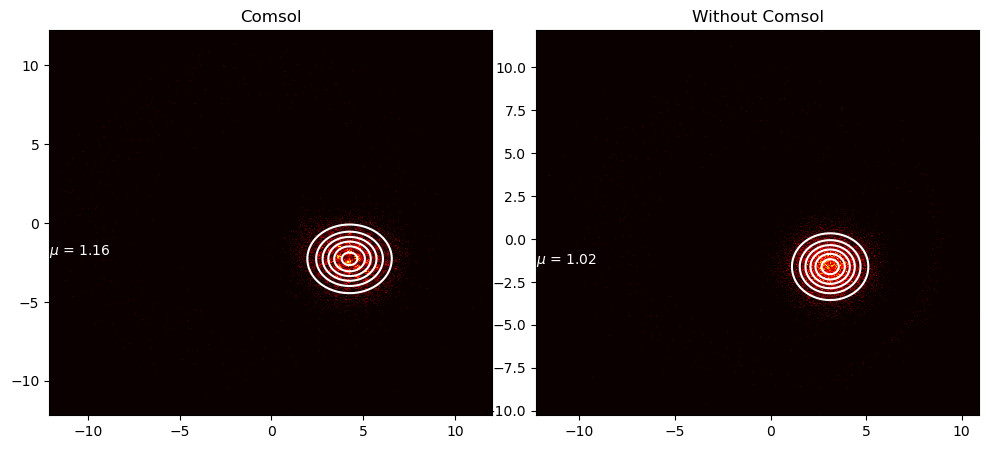

In [32]:
f,ax=plt.subplots(1,2,figsize=(12,5))
EvntID=13
Event=Cm["Camera"]["Event"]
EventMask=Event==EvntID
binsize=400
ax[0].set_title("Comsol")
X=Cm["Camera"]["x"][EventMask]
Y=Cm["Camera"]["y"][EventMask]
Event=Cm["Diffusion"]["Event"]
EventMask=Event==EvntID
MaxMax=Cm["Diffusion"]["dt"][EventMask]<np.max(Cm["Diffusion"]["dt"][EventMask])
dt=Cm["Diffusion"]["dt"][EventMask][MaxMax]

ComsolFit=FitSumsof_N_2DGaussian(X,Y,ax[0],NGaussians=1,isPlot=True,isPrint=False,binsize=binsize)
print(ComsolFit[1])
Event=NoCm["Camera"]["Event"]
EventMask=Event==EvntID

ax[1].set_title("Without Comsol")
X=NoCm["Camera"]["x"][EventMask]
Y=NoCm["Camera"]["y"][EventMask]
Event=NoCm["Diffusion"]["Event"]
EventMask=Event==EvntID
#MaxMax=_4cm_NoComsol["Diffusion"]["dt"][EventMask]<np.max(_4cm_NoComsol["Diffusion"]["dt"][EventMask])
dt_NoComsol=NoCm["Diffusion"]["dt"][EventMask]
No_ComsolFit=FitSumsof_N_2DGaussian(X,Y,ax[1],NGaussians=1,isPlot=True,isPrint=False,binsize=binsize)
print(No_ComsolFit[1])

plt.subplots_adjust(wspace=0.1, hspace=0.1)

#plt.figure(figsize=(15,15),dpi=300)
#plt.title("Dts")

#plt.hist(dt,label="Without Comsol")
#print(dt)

In [33]:
print(No_ComsolFit[1])
print(ComsolFit[1])


[array([1.03]), array([1.]), array([1.015]), array([3.12]), array([-1.61])]
[array([1.19]), array([1.13]), array([1.16]), array([4.26]), array([-2.27])]


[3.7850254 3.8747945 3.5979183 ... 5.1844234 4.9667172 4.828923 ]
amps [336.]
means [4.04551556]
sigmas [1.93279071]
------ Initials ------
[336.           4.04551556   1.93279071]
Peaks []
Sigma Values [1.20457734] and  Total 1.4510065659936007
Fit Results
[235.08545694   4.23981537   1.20457734]
-------------- Fit Results --------------
(array([235.08545694,   4.23981537,   1.20457734]), array([[ 5.28417527e+00,  9.49833303e-10, -1.80507331e-02],
       [ 9.49833303e-10,  1.84983818e-04, -4.87690697e-12],
       [-1.80507331e-02, -4.87690697e-12,  1.84983817e-04]]))
amps [1388.]
means [-2.17880573]
sigmas [1.62266936]
------ Initials ------
[1388.           -2.17880573    1.62266936]
Peaks []
Sigma Values [1.13582606] and  Total 1.290100845741228
Fit Results
[ 1.26222834e+03 -2.30759622e+00  1.13582606e+00]
-------------- Fit Results --------------
(array([ 1.26222834e+03, -2.30759622e+00,  1.13582606e+00]), array([[ 3.62143941e+01,  6.95994683e-10, -2.17251466e-02],
       [ 6.95994

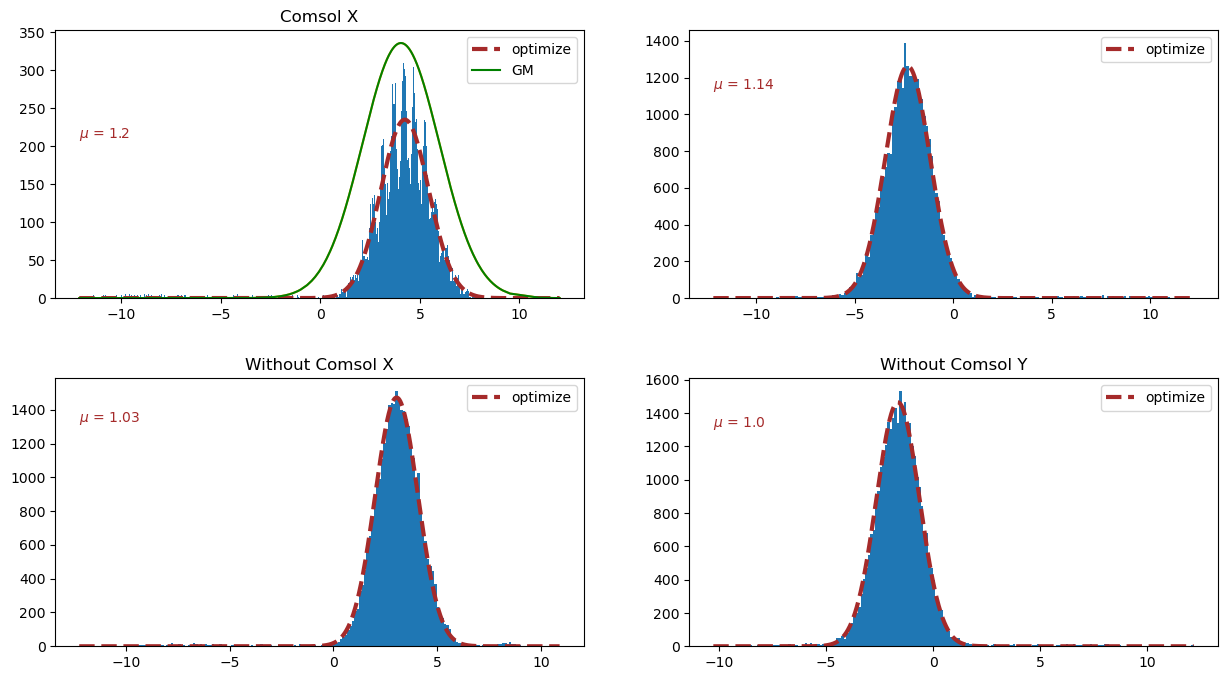

In [34]:
f,ax=plt.subplots(2,2,figsize=(15,8))
Event=Cm["Camera"]["Event"]
EventMask=Event==EvntID

X=Cm["Camera"]["x"][EventMask]
Y=Cm["Camera"]["y"][EventMask]
print(X)
## First Hist
ax[0,0].set_title("Comsol X")

sample=np.random.normal(np.mean(X)-100,0.2,100)
testconvolve=np.convolve(sample,X,mode="same")
#print(sample)
FitSumsof_N_1DGaussian(X,ax[0,0],NGaussians=1,binsize=1000,isPlotGM=True)
#FitSumsof_N_1DGaussian(testconvolve,ax[0,0],NGaussians=1,binsize=1000,isPlotGM=True)
#plt.hist(testconvolve,bins=1000)
#FitSumsof_N_1DGaussian(testconvolve.flatten(),ax[0,0],NGaussians=1,binsize=1000,isPlotGM=True)

#ax[0,0].set_xlim(-5,1)
## Second Hist
FitSumsof_N_1DGaussian(Y,ax[0,1],NGaussians=1)


########################################
Event=NoCm["Camera"]["Event"]
EventMask=Event==EvntID

ax[1,0].set_title("Without Comsol X")
X=NoCm["Camera"]["x"][EventMask]
Y=NoCm["Camera"]["y"][EventMask]
ax[1,1].set_title("Without Comsol Y")

### Third Hist
FitSumsof_N_1DGaussian(X,ax[1,0],NGaussians=1,isPlot=True)

### Fourth Hist
FitSumsof_N_1DGaussian(Y,ax[1,1],NGaussians=1,isPlot=True)

plt.subplots_adjust(wspace=0.2, hspace=0.3)

amps [5488.]
means [-18.54093499]
sigmas [4.71991063]
------ Initials ------
[ 5.48800000e+03 -1.85409350e+01  4.71991063e+00]
Peaks []
Sigma Values [4.79049915] and  Total 22.948882062436233
Fit Results
[3145.68333919  -18.5909614     4.79049915]
-------------- Fit Results --------------
(array([3145.68333919,  -18.5909614 ,    4.79049915]), array([[ 1.94682550e+04,  1.27635553e-03, -1.97681644e+01],
       [ 1.27635553e-03,  6.01969282e-02, -4.23972401e-06],
       [-1.97681644e+01, -4.23972401e-06,  6.02100994e-02]]))
amps [3704.]
means [9.91125693]
sigmas [4.68865013]
------ Initials ------
[3704.            9.91125693    4.68865013]
Peaks []
Sigma Values [4.6828655] and  Total 21.929229333380086
Fit Results
[3474.85807207    9.76836752    4.6828655 ]
-------------- Fit Results --------------
(array([3474.85807207,    9.76836752,    4.6828655 ]), array([[ 4.15061467e+02, -1.29181069e-07, -3.72903487e-01],
       [-1.29181069e-07,  1.00507982e-03,  3.87399273e-10],
       [-3.729034

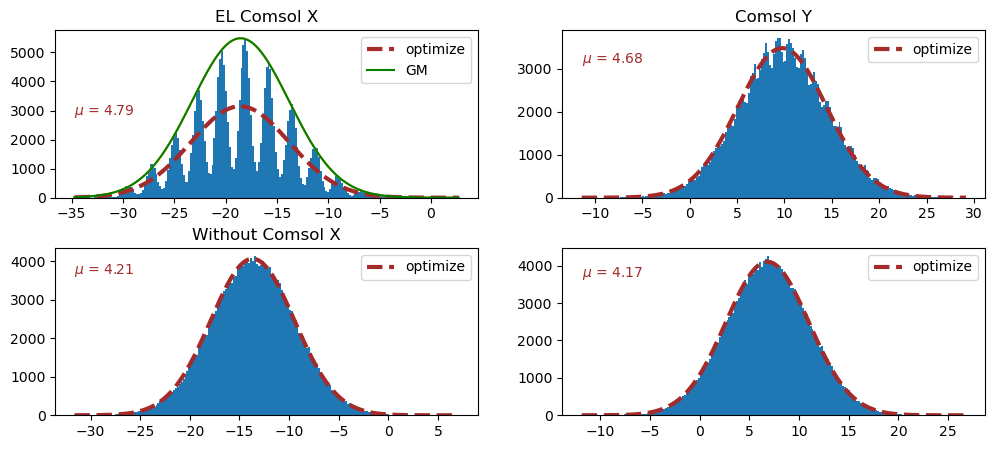

In [35]:
f,ax=plt.subplots(2,2,figsize=(12,5))
Event=Cm["EL"]["Event"]
EventMask=Event==EvntID
binsize=300

X=Cm["EL"]["X"][EventMask]
Y=Cm["EL"]["Y"][EventMask]

#correlation = np.corrcoef(X,Y,ddof=12)[0, 1]
#print(f"Correlation {round(correlation,3)}")
### First Hist
ax[0,0].set_title("EL Comsol X")

Fit1=FitSumsof_N_1DGaussian(X,ax[0,0],NGaussians=1,isPlot=True,isPlotGM=True)

## Second Hist
ax[0,1].set_title("Comsol Y")

FitSumsof_N_1DGaussian(Y,ax[0,1],NGaussians=1,isPlot=True)


Event=NoCm["EL"]["Event"]
EventMask=Event==EvntID

ax[1,0].set_title("Without Comsol X")
X=NoCm["EL"]["X"][EventMask]
Y=NoCm["EL"]["Y"][EventMask]
ax[1,0].set_title("Without Comsol X")

#### Third Hist
FitSumsof_N_1DGaussian(X,ax[1,0],NGaussians=1,isPlot=True)

#FitSumsof_N_1DGaussian(X-5,ax[0,0],NGaussians=1,isPlot=True)
#samples = np.random.normal(loc=-1.85e1, scale=4.719, size=10000)
#weight=np.ones_like(samples)*40
#ax[0,0].hist(samples,weights=weight,bins=200,color="yellow")
#### Fourth Hist
FitSumsof_N_1DGaussian(Y,ax[1,1],NGaussians=1,isPlot=True)
#FitSumsof_N_1DGaussian(Y,ax[0,1],NGaussians=1,isPlot=True)
plt.subplots_adjust(wspace=0.2, hspace=0.3)

In [36]:
print(np.sqrt(np.sum(Fit1[1]**2)))

4.790499145437376


In [37]:
Fit1[1]

array([4.79049915])

Amp [1.]
Means [-18.54093499   9.91125693]
sigma [4.71991063 4.68865013]
Initials [  1.         -18.54093499   4.71991063   9.91125693   4.68865013
   0.        ]
FitResult [ 2.41235400e+01 -1.84702942e+01  4.81199461e+00  9.88376257e+00
  4.70654026e+00 -5.64079884e-03]
Fit Results


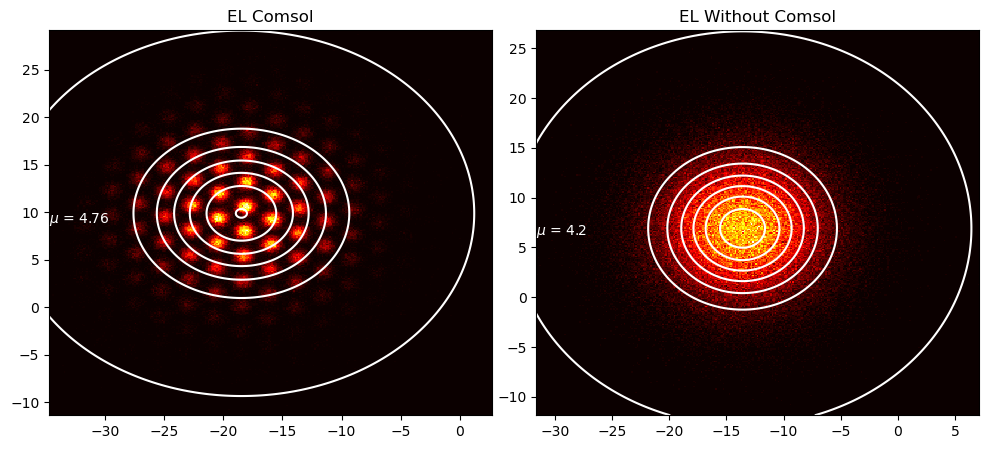

In [38]:
f,ax=plt.subplots(1,2,figsize=(12,5))
Event=Cm["EL"]["Event"]
EventMask=Event==EvntID
binsize=300
ax[0].set_title("EL Comsol")
X=Cm["EL"]["X"][EventMask]
Y=Cm["EL"]["Y"][EventMask]
EL_Comsol=FitSumsof_N_2DGaussian(X,Y,ax[0],NGaussians=1,isPlot=True,isPrint=True,binsize=binsize)



Event=NoCm["EL"]["Event"]
EventMask=Event==EvntID

ax[1].set_title("EL Without Comsol")
X=NoCm["EL"]["X"][EventMask]
Y=NoCm["EL"]["Y"][EventMask]
EL_NoComsol=FitSumsof_N_2DGaussian(X,Y,ax[1],NGaussians=1,isPlot=True,isPrint=False,binsize=binsize)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

In [39]:
## To excract the correction factor
def CreateDistribution(comsol,Nocomsol,key=["EL","X","Y","Z"],bins=[50,50],isPlot=[True,False]):
    Limit=100
    SigmasX_=np.array([])
    SigmasY_=np.array([])
    MeanSigmas_=np.array([])
    MeanX_=np.array([])
    MeanY_=np.array([])
    Event=comsol[key[0]]["Event"]
    UniqueOnes=np.unique(Event)
    print(f"Running Comsol Events {len(UniqueOnes)} ...")
    Count_1=0
    for Evt in UniqueOnes:
        EventMask=Event==Evt
        #print(f"Event {Evt}")
        X=comsol[key[0]][key[1]][EventMask]
        Y=comsol[key[0]][key[2]][EventMask]
        if(len(X)<Limit):
            Count_1=Count_1+1
            continue
        #print(f"Event {Evt} lengths X is {len(X)} Y is {len(Y)}")
        fitresult=FitSumsof_N_2DGaussian(X,Y,None,NGaussians=1,isPlot=isPlot[1],isPrint=False,binsize=bins[0])
        SigmasX_=np.append(SigmasX_,fitresult[1][0])
        SigmasY_=np.append(SigmasY_,fitresult[1][1])
        MeanSigmas_=np.append(MeanSigmas_,fitresult[1][2])
        MeanX_=np.append(MeanX_,fitresult[1][3])
        MeanY_=np.append(MeanY_,fitresult[1][4])

    
   
    Event=Nocomsol[key[0]]["Event"]
    _SigmasX=np.array([])
    _SigmasY=np.array([])
    _MeanSigmas=np.array([])
    _MeanX=np.array([])
    _MeanY=np.array([])
    UniqueOnes=np.unique(Event)
    
    print(f"Running Uniform Field Events {len(UniqueOnes)} ...")
    
    Count_2=0
    for Evt in UniqueOnes:
        EventMask=Event==Evt
        #print(f"Event {Evt}")
        X=Nocomsol[key[0]][key[1]][EventMask]
        Y=Nocomsol[key[0]][key[2]][EventMask]
        if(len(X)<Limit):
            Count_2=Count_2+1
            continue
        fitresult=FitSumsof_N_2DGaussian(X,Y,None,NGaussians=1,isPlot=isPlot[1],isPrint=False,binsize=bins[0])
        _SigmasX=np.append(_SigmasX,fitresult[1][0])
        _SigmasY=np.append(_SigmasY,fitresult[1][1])
        _MeanSigmas=np.append(_MeanSigmas,fitresult[1][2])
        _MeanX=np.append(_MeanX,fitresult[1][3])
        _MeanY=np.append(_MeanY,fitresult[1][4])
        
    
    '''if(Count_1!=Count_2):
        CountMin=np.max([Count_1,Count_2])
        if(Count_1==CountMin):
            _SigmasX=_SigmasX[:-CountMin]
            _SigmasY=_SigmasY[:-CountMin]
            _MeanSigmas=_MeanSigmas[:-CountMin]
        elif(Count_2==CountMin):
            SigmasX_=SigmasX_[:-CountMin]
            SigmasY_=SigmasY_[:-CountMin]
            MeanSigmas_=MeanSigmas_[:-CountMin] 
    '''
    
    
    
    SigXMin=np.min([np.min(SigmasX_),np.min(_SigmasX)])
    SigYMin=np.min([np.min(SigmasY_),np.min(_SigmasY)])
    MeanSigMin=np.min([np.min(MeanSigmas_),np.min(_MeanSigmas)])
    SigXMax=np.max([np.max(SigmasX_),np.max(_SigmasX)])
    SigYMax=np.max([np.max(SigmasY_),np.max(_SigmasY)])
    MeanSigMax=np.max([np.max(MeanSigmas_),np.max(_MeanSigmas)])
   
    
    SigXBins=np.linspace(SigXMin,SigXMax,bins[1])
    SigYBins=np.linspace(SigYMin,SigYMax,bins[1])
    MeanSigBins=np.linspace(MeanSigMin,MeanSigMax,bins[1])
    
    
    factorX=np.mean(_SigmasX)/np.mean(SigmasX_)
    factorY=np.mean(_SigmasY)/np.mean(SigmasY_)
    factorMean=np.mean(_MeanSigmas)/np.mean(MeanSigmas_)
 
    if(isPlot[0]):    
        f,ax=plt.subplots(2,3,figsize=(12,5))
        ax[0,0].set_title("Comsol X")
        rx1=ax[0,0].hist(SigmasX_,bins=SigXBins)
        ax[0,1].set_title("Y")
        ry1=ax[0,1].hist(SigmasY_,bins=SigYBins)
        ax[0,2].set_title("Mean")
        rm1=ax[0,2].hist(MeanSigmas_,bins=MeanSigBins)    
        rx2=ax[1,0].hist(_SigmasX,bins=SigXBins)
        ry2=ax[1,1].hist(_SigmasY,bins=SigYBins)    
        rm2=ax[1,2].hist(_MeanSigmas,bins=MeanSigBins)
        #ax[2,0].hist(factorXs,bins=bins[1])
        #ax[2,1].hist(factorYs,bins=bins[1])    
        #ax[2,2].hist(factorMeans,bins=bins[1])
    
    
    print(f" FactorX {round(factorX,2)} FactorY {round(factorY,2)} FactorMean {round(factorMean,2)}")
    All={"Factors":[factorX,factorY,factorMean],
         "ComsolSigmas":[SigmasX_,SigmasY_,MeanSigmas_],
         "Sigmas":[_SigmasX,_SigmasY,_MeanSigmas],
         "ComsolMeans":[MeanX_,MeanY_],
         "Means":[_MeanX,_MeanY]}
    return All
    

Running Comsol Events 100 ...
Running Uniform Field Events 100 ...
 FactorX 0.93 FactorY 0.89 FactorMean 0.91


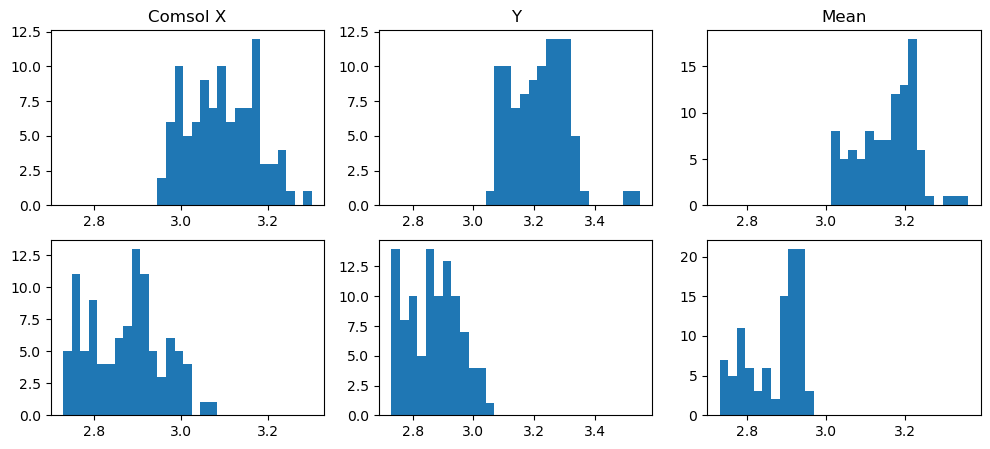

In [40]:
_Res4cm=CreateDistribution(_4cm,_4cm_NoComsol,isPlot=[True,False],bins=[300,30])

Running Comsol Events 100 ...
Running Uniform Field Events 100 ...
 FactorX 0.86 FactorY 0.9 FactorMean 0.88


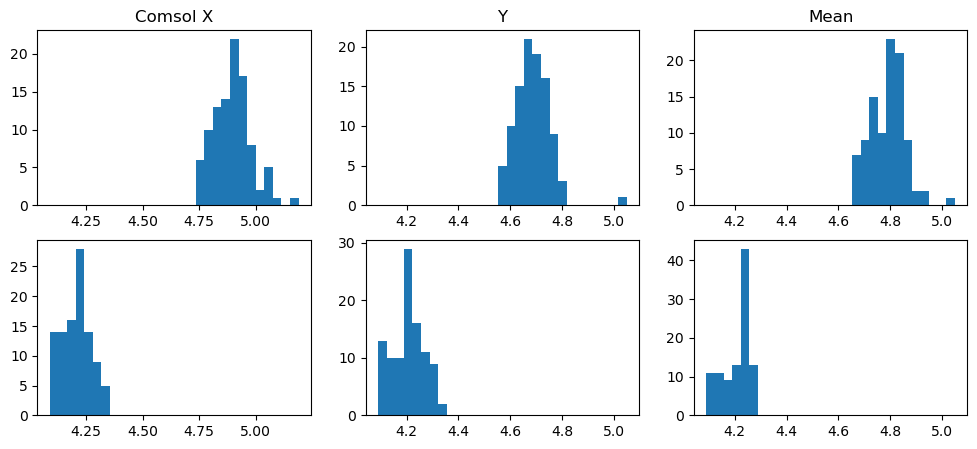

In [41]:
_Res9cm=CreateDistribution(_9cm,_9cm_NoComsol,isPlot=[True,False],bins=[100,30])

Running Comsol Events 100 ...
Running Uniform Field Events 100 ...
 FactorX 0.9 FactorY 0.87 FactorMean 0.89


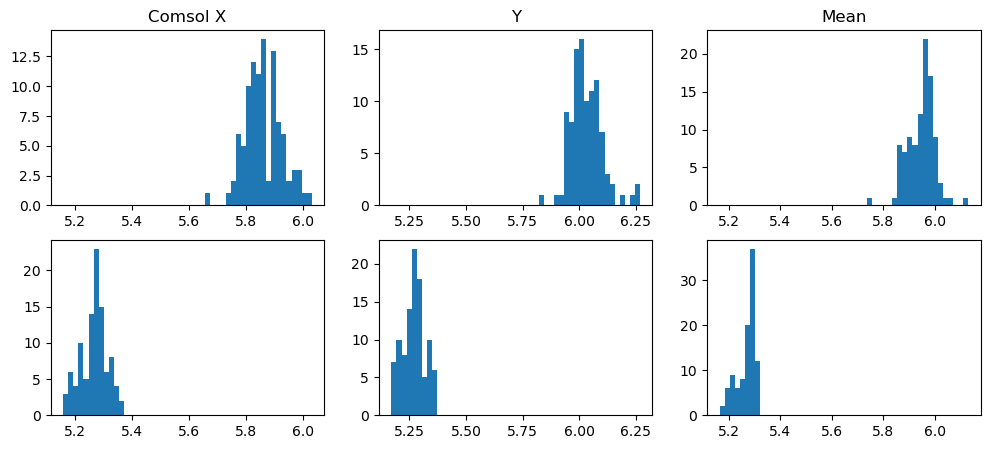

In [42]:
_Res9cm=CreateDistribution(_14cm,_14cm_NoComsol,isPlot=[True,False])